# Notebook 4 — LSTM Model
**Նպատակ:** Long Short-Term Memory ցանցով գնի ուղղության կանխատեսում  
**Ենթահարց 6:** LSTM vs CNN vs Transformer — ո՞րն է ավելի արդյունավետ

## 1. Libraries & Load Data

In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings, os
warnings.filterwarnings('ignore')
os.chdir('/Users/lusine/Desktop')
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

print(f'TensorFlow version: {tf.__version__}')

with open('data/features/model_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_seq']
X_val   = data['X_val_seq']
X_test  = data['X_test_seq']
y_train = data['y_train_seq']
y_val   = data['y_val_seq']
y_test  = data['y_test_seq']
N_FEATURES = data['n_features']
SEQ_LEN    = data['SEQUENCE_LEN']

# Convert labels -1,0,1 → 0,1,2 for keras
y_train_k = y_train + 1
y_val_k   = y_val   + 1
y_test_k  = y_test  + 1

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

TensorFlow version: 2.21.0
X_train: (9984, 30, 44)  y_train: (9984,)
X_val:   (2116, 30, 44)    y_val:   (2116,)
X_test:  (2116, 30, 44)   y_test:  (2116,)


## 2. LSTM Model Architecture

In [4]:
def build_lstm(seq_len, n_features, n_classes=3):
    model = Sequential([
        Input(shape=(seq_len, n_features)),

        # Layer 1 — Bidirectional LSTM
        Bidirectional(LSTM(128, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2 — LSTM
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3 — LSTM
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Dense head
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(SEQ_LEN, N_FEATURES)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       177,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,307 (1.05 MB)

 Trainable params: 273,603 (1.04 MB)

 Non-trainable params: 704 (2.75 KB)

## 3. Training

In [5]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('models/lstm_best.keras', save_best_only=True, monitor='val_loss')
]

history = lstm_model.fit(
    X_train, y_train_k,
    validation_data=(X_val, y_val_k),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.3916 - loss: 1.1686 - val_accuracy: 0.3634 - val_loss: 1.0854 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.4147 - loss: 1.0954 - val_accuracy: 0.3771 - val_loss: 1.0880 - learning_rate: 0.0010
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.4331 - loss: 1.0721 - val_accuracy: 0.3781 - val_loss: 1.0967 - learning_rate: 0.0010
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.4393 - loss: 1.0641 - val_accuracy: 0.3856 - val_loss: 1.1068 - learning_rate: 0.0010
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.4421 - loss: 1.0571 - val_accuracy: 0.3752 - val_loss: 1.1003 - learning_rate: 0.0010
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.4522 - loss: 1.0478 - val_accuracy: 0.3582 - val_loss: 1.1161 - learning_rate: 0.0010
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.4

## 4. Training History Visualization

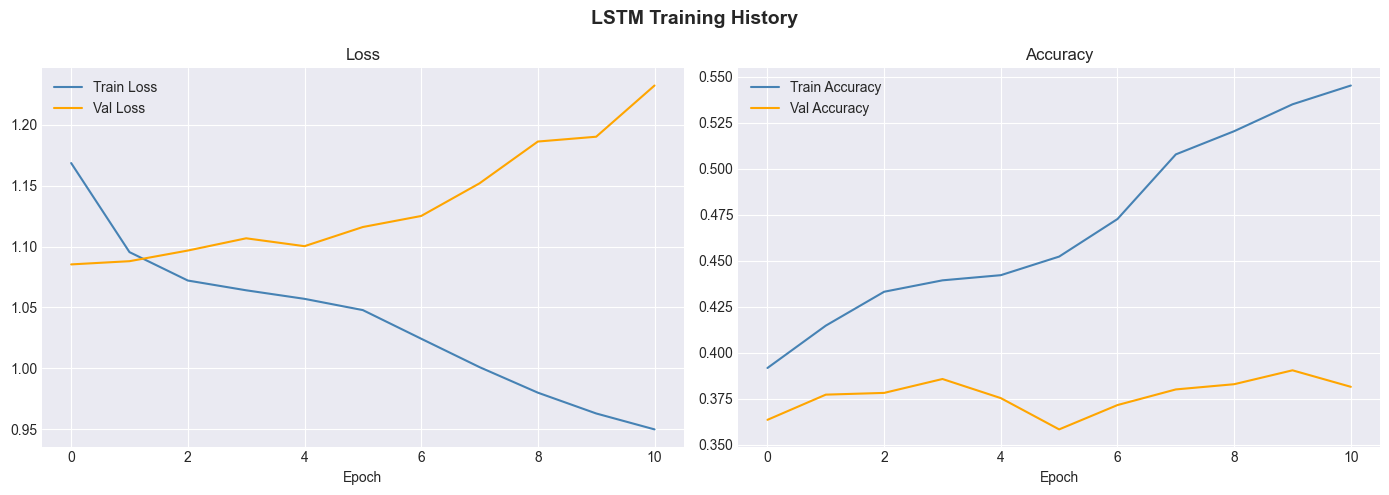

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/lstm_training_history.png', dpi=150)
plt.show()

## 5. Evaluation on Test Set

In [7]:
y_pred_prob = lstm_model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1) - 1  # back to -1,0,1

# Metrics
acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print('=== LSTM Test Results ===')
print(f'Accuracy:  {acc:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Down(-1)', 'Neutral(0)', 'Up(1)']))

# Save results
lstm_results = {
    'model': 'LSTM',
    'accuracy':  acc,
    'f1':        f1,
    'precision': prec,
    'recall':    rec,
    'y_pred':    y_pred,
    'y_pred_prob': y_pred_prob,
    'history':   history.history
}
with open('results/lstm_results.pkl', 'wb') as f:
    pickle.dump(lstm_results, f)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
=== LSTM Test Results ===
Accuracy:  0.3889
F1 Score:  0.3824
Precision: 0.3930
Recall:    0.3889

Classification Report:
              precision    recall  f1-score   support

    Down(-1)       0.38      0.49      0.43       787
  Neutral(0)       0.42      0.23      0.30       490
       Up(1)       0.39      0.39      0.39       839

    accuracy                           0.39      2116
   macro avg       0.40      0.37      0.37      2116
weighted avg       0.39      0.39      0.38      2116



## 6. Confusion Matrix & Per-Class Analysis

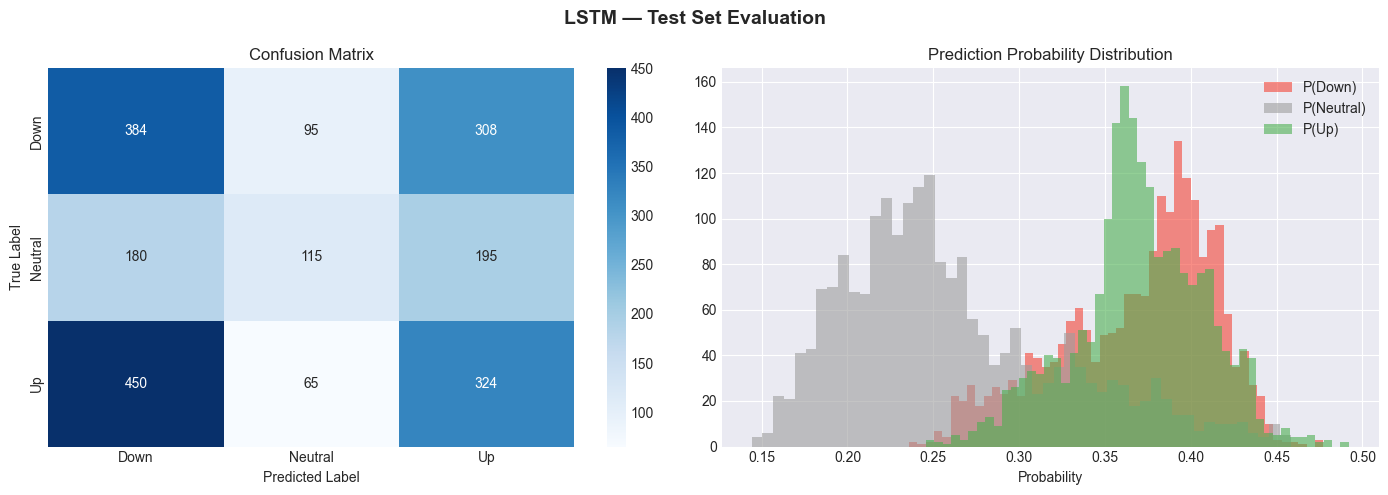

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM — Test Set Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down', 'Neutral', 'Up'],
            yticklabels=['Down', 'Neutral', 'Up'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Prediction probability distribution
axes[1].hist(y_pred_prob[:, 0], bins=50, alpha=0.6, label='P(Down)',    color='#F44336')
axes[1].hist(y_pred_prob[:, 1], bins=50, alpha=0.6, label='P(Neutral)', color='#9E9E9E')
axes[1].hist(y_pred_prob[:, 2], bins=50, alpha=0.6, label='P(Up)',      color='#4CAF50')
axes[1].set_title('Prediction Probability Distribution')
axes[1].set_xlabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/lstm_evaluation.png', dpi=150)
plt.show()

## 7. Feature Group Importance Analysis
Ենթահարցերի համար — որ feature group-ն է ամենաշատ նպաստում։

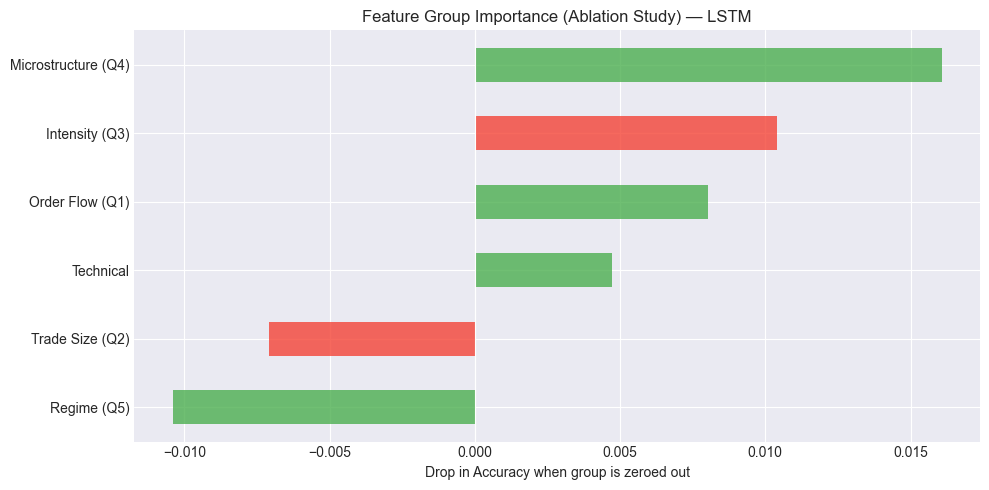

Feature Group Importance:
  Microstructure (Q4): +0.0161
  Intensity (Q3): +0.0104
  Order Flow (Q1): +0.0080
  Technical: +0.0047
  Trade Size (Q2): -0.0071
  Regime (Q5): -0.0104


In [9]:
FEATURE_GROUPS = {
    'Order Flow (Q1)':      list(range(0, 10)),
    'Trade Size (Q2)':      list(range(10, 18)),
    'Intensity (Q3)':       list(range(18, 28)),
    'Microstructure (Q4)':  list(range(28, 34)),
    'Regime (Q5)':          list(range(34, 39)),
    'Technical':            list(range(39, 44)),
}

baseline_acc = acc
group_importance = {}

for group_name, indices in FEATURE_GROUPS.items():
    X_test_ablated = X_test.copy()
    X_test_ablated[:, :, indices] = 0  # zero out this group
    y_pred_abl = np.argmax(lstm_model.predict(X_test_ablated, verbose=0), axis=1) - 1
    abl_acc = accuracy_score(y_test, y_pred_abl)
    group_importance[group_name] = baseline_acc - abl_acc  # drop in accuracy

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in group_importance.values()]
pd.Series(group_importance).sort_values().plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Feature Group Importance (Ablation Study) — LSTM', fontsize=12)
ax.set_xlabel('Drop in Accuracy when group is zeroed out')
plt.tight_layout()
plt.savefig('results/lstm_feature_importance.png', dpi=150)
plt.show()

print('Feature Group Importance:')
for k, v in sorted(group_importance.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:+.4f}')

**Հաջորդ → Notebook 5: CNN Model**